***Студент: Овчинников Андрей Дмитриевич***

***Группа: 2510***

***Вариант: 163***

# **Математический анализ I. Лабораторная работа №2. Часть 1**

<font color=#FF5EDD>**Правила:**</font>.
1. Все необходимо считать и выполнять с помощью кода. (Где необходимо, не забывайте пояснять текстом).
2. Запрещено менять название файла!
3. ***не допускается*** использование методов, которые не были изучены в этой и предыдущей лабораторных работах.
   
*P.S. Если у Вас будут вопросы, обращайтесь к [Алёне Числовой](https://t.me/Alyona_Chislova).*

**Перед отправкой обязательно перезапустите ядро и скомпилируйте весь ноутбук заново!**

Убедитесь, что Вы использовали только наш блок со всеми импортами библиотек. Если Вы писали код в Jupyter/VS Code/PyCharm и т.д.(в приложениях со своими встроенными импортами), обязательно запустите свой ноутбук в Google Colab (в нем нет своих встроенных импортов), чтобы убедиться, что все работает!) Ваша работа будет проверяться в Google Colab.

**[Теория](https://drive.google.com/drive/folders/1Ud0kFr-HxAhzG7fZoz8d3AaPm3xk__-c?usp=sharing)** - по этой ссылке можно посмотреть всю теорию с конспектом и его разбором для этой лабораторной работы.

## **<font color=#10A1C4> *Содержание:</font>***

**Примечание:** в Google Colab в содержании ссылки на главы теории и на задачи работают только когда названия разделов не скрыты

### **<font color=#10A1C4>*Содержание по задачам:</font>***

1. [Раздел: интерполяция](#interpolation_1):
- [Задача 1](#task_1) <br>
- [Задача 2](#task_2) <br>
2. [Раздел: функции нескольких переменных:](#function_several_variables)
- [Задача 3](#task_3) <br>
- [Задача 4](#task_4) <br>
- [Задача 5](#task_5) <br>


<a name="interpolation_1"></a>
## **<font color=#02AF02>1. Раздел: интерполяция</font>**

<a name="task_1"></a>
**<font color=#FF5EDD>Задача 1**</font>

Вы - аналитик в хедж-фонде. В системе сбора данных произошел технический сбой: часть котировок Биткоина (BTC-USD) была утеряна. Для корректной работы торговых роботов необходимо восстановить пропущенные значения.

<font color=#FF5EDD>*Ваша задача:*</font> Провести исследование и определить, какой метод интерполяции является наиболее надежным в разных рыночных условиях (Вам даны два разных периода), и какой из них создает максимальные риски для капитала компании.

<font color=#FF5EDD>Параметры исследования</font> (значения их можно менять):

* Количество анализируемых торговых дней (сколько последних точек периода берем (None = весь период)) (`S_SIZE`): 100 точек (дней).
* Количество пропусков (переменная, определяющая количество искусственно созданных пропусков (дырок)) (`n_missing`): 15 точек
* Сценарии: Сравнить Period1 и Period2.

Подготовка данных: используйте выданную функцию `prepare_data_and_sabotage`.

<font color=#FF5EDD>***Этап 1: Реализация методов интерполяции***</font>

используя библиотеку `Pandas` (метод `.interpolate()`), восстановите данные в колонке `Corrupted` тремя способами:
* Линейная интерполяция (linear) — соединение точек прямыми линиями.
* Кубический сплайн (spline, order=3) — построение гладкой кривой.
* Полином 5-й степени (polynomial или spline, order=5) — попытка учесть сложные изгибы тренда.

<font color=#FF5EDD>***Этап 2: Расчет метрик точности***</font>

Для каждого метода рассчитайте ошибки только в местах пропусков (используйте mask):
* <font color=#FF5EDD>***RMSE***</font> (Root Mean Squared Error): среднеквадратичная ошибка. Показывает общее качество восстановления. Формула: $\sqrt{\frac{1}{N} \sum (y_{real} - y_{pred})^2}$ Поскольку ошибка возводится в квадрат, RMSE жестоко штрафует за большие промахи. Когда важна: Если вы боитесь редких, но метких ошибок модели.
* <font color=#FF5EDD>***Max Error***</font> (Worst Case Scenario): максимальное отклонение восстановленной цены от реальной в одной точке. Формула: $max(|y_{real} - y_{pred}|)$ В трейдинге это критическая метрика: огромная ошибка в одной точке может привести к ложному срабатыванию стоп-лосса или ликвидации позиции. Это главная метрика риска.
* (по желанию можно добавить MAE (Mean Absolute Error): Формула: $\frac{1}{N} \sum |y_{real} - y_{pred}|$ Средняя ошибка в долларах. Сколько мы теряем в среднем на каждой сделке из-за кривых данных?)

<font color=#FF5EDD>***Этап 3: Тестирование***</font>

Напишите цикл, который будет увеличивать количество пропусков (n_missing) от 5 до 40 с шагом 5. Для каждого шага рассчитайте RMSE и Max Error для всех трех методов. Сохраните результаты в структуру данных (например, словарь или DataFrame).

<font color=#FF5EDD>***Этап 4: Визуализация результатов***</font>

Необходимо построить два типа графиков:
* <font color=#FF5EDD>***График цен:***</font> Два графика (для Period1 и Period2). Сравнение оригинала и всех трех линий интерполяции на одном окне (чтобы увидеть «галлюцинации» моделей глазами). Отменить крестиками точки, которые мы искуственно убрали (наши потерянные данные)
* <font color=#FF5EDD>***График деградации точности:***</font> Два графика (для Period1 и Period2), где по горизонтали — количество пропусков, а по вертикали — ошибки (RMSE на основной оси, Max Error на вспомогательной).

<font color=#FF5EDD>**Вопросы:**</font>

1. Сравните два периода. Кратко опиши отличия.

2. Риск-менеджмент: Представьте, что на оси Y это цена вашего актива. Какое максимальное отклонение в долларах (Max Error) допустил Сплайн? Если бы вы торговали с кредитным плечом, привела бы такая "галлюцинация" алгоритма к банкротству?

3. Эффект «Перелета»: Найдите на графике место, где цена резко меняла направление (V-образный разворот). Как повел себя Сплайн и Полином? Нарисовали ли они цену ниже реального дна или выше реального пика?

4. Края данных: Что происходит с Полиномом и Сплайном в самом начале и в самом конце графика? Насколько им можно доверять без "соседей" с обеих сторон?

5.  RMSE информативность: Может ли быть так, что средняя ошибка (RMSE) у сплайна ниже, чем у линейной интерполяции, но при этом торговать по его данным опаснее?

6. Бритва Оккама: Есть ли смысл использовать сложные методы (сплайны), если линейная интерполяция дает сопоставимую или лучшую точность при меньшем риске огромных Max Error?

7. Как методы ведут себя на более коротких отрезках данных? Повлияет ли это на точность полиномов? Попробуйте поиграться с S_SIZE (например, измените его на 50), чтобы это увидеть

8. Какой метод Вы бы выбрали для работы в условиях высокой волатильности и почему? 
Какой метод Вы бы внедрили в реальную торговую систему фонда? Обоснуйте выбор.

*Примечание: для удобства можете разбить свое решение на несколько ячеек.* 


Загрузка Period1: с 2023-04-01 по 2023-09-01...
Загрузка Period2: с 2022-05-01 по 2022-07-01...
Метрики для Period2 при N_DROPPED = 15:
           RMSE  Max Error      MAE
Method                             
Linear   892.80    1635.47   725.94
Spline  1322.82    2758.72  1050.63
Poly_5  1861.76    5344.25  1335.91

Сравнение Period1 и Period2 при одинаковых параметрах:

Period1
           RMSE  Max Error     MAE
Method                            
Linear   332.54     784.33  223.73
Spline   468.69    1202.05  356.14
Poly_5  1086.41    3589.77  675.89

Period2
           RMSE  Max Error      MAE
Method                             
Linear   892.80    1635.47   725.94
Spline  1322.82    2758.72  1050.63
Poly_5  1861.76    5344.25  1335.91


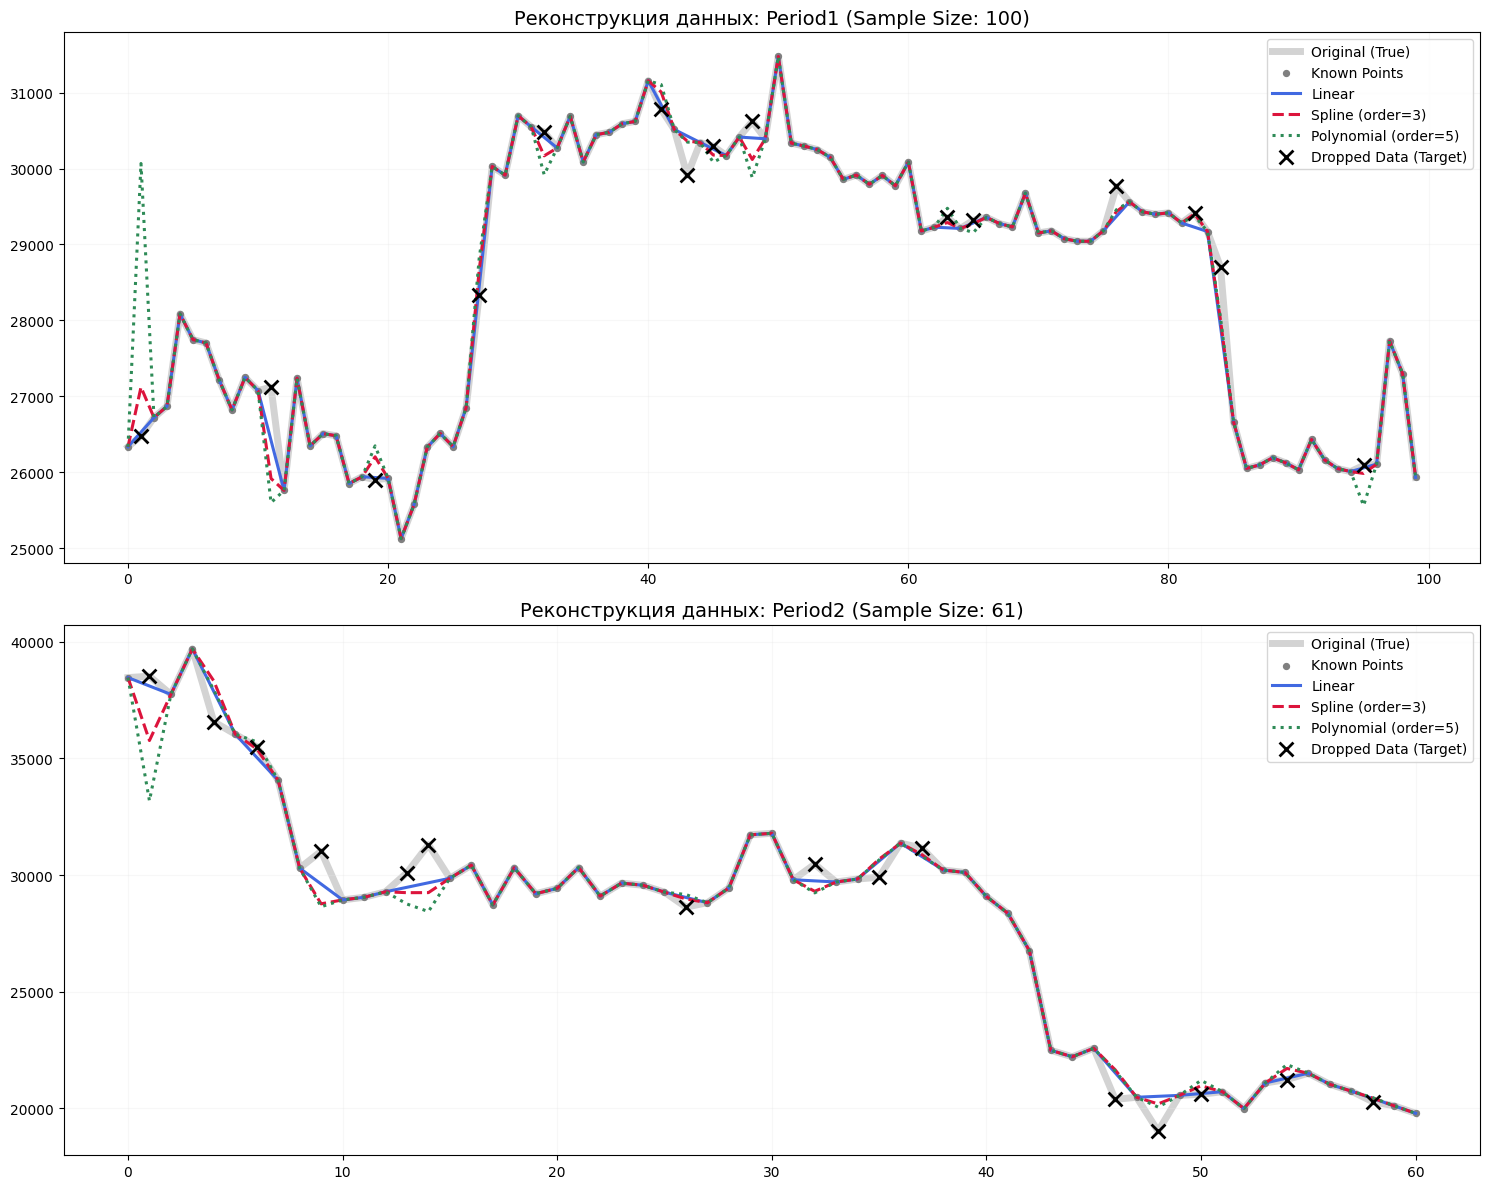

Загрузка Period1: с 2023-04-01 по 2023-09-01...
Загрузка Period1: с 2023-04-01 по 2023-09-01...
Загрузка Period1: с 2023-04-01 по 2023-09-01...
Загрузка Period1: с 2023-04-01 по 2023-09-01...
Загрузка Period1: с 2023-04-01 по 2023-09-01...
Загрузка Period1: с 2023-04-01 по 2023-09-01...
Загрузка Period1: с 2023-04-01 по 2023-09-01...
Загрузка Period1: с 2023-04-01 по 2023-09-01...
Загрузка Period2: с 2022-05-01 по 2022-07-01...
Загрузка Period2: с 2022-05-01 по 2022-07-01...
Загрузка Period2: с 2022-05-01 по 2022-07-01...
Загрузка Period2: с 2022-05-01 по 2022-07-01...
Загрузка Period2: с 2022-05-01 по 2022-07-01...
Загрузка Period2: с 2022-05-01 по 2022-07-01...
Загрузка Period2: с 2022-05-01 по 2022-07-01...
Загрузка Period2: с 2022-05-01 по 2022-07-01...


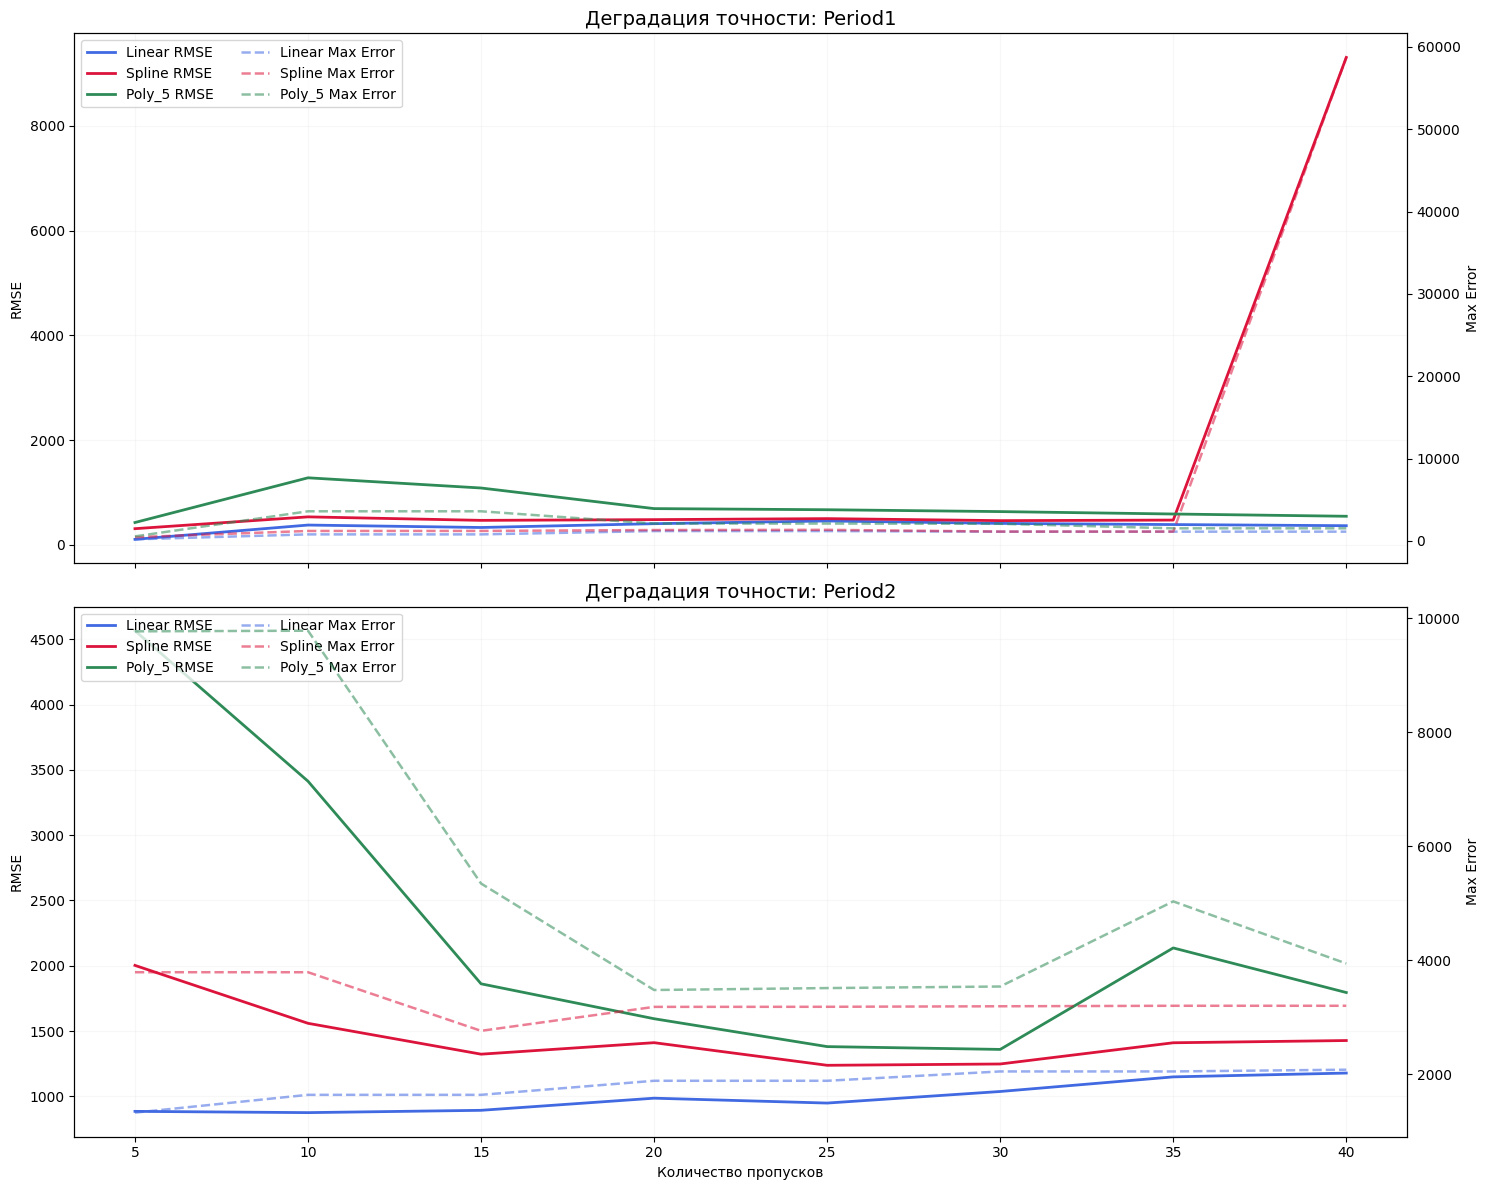

Загрузка Period1: с 2023-04-01 по 2023-09-01...
Загрузка Period2: с 2022-05-01 по 2022-07-01...

Ответы на вопросы:
1. Period1 заметно спокойнее: при одинаковых параметрах у линейной интерполяции RMSE = 332.54, а у Period2 уже 892.80. Во втором периоде все методы ошибаются сильнее, значит рынок там более волатильный.
2. Максимальный риск у сплайна в Period1: Max Error = 58729.29$ при 40 пропусках. Для торговли с плечом такой выброс опасен: ложный стоп или ликвидация вполне возможны.
2. Максимальный риск у сплайна в Period2: Max Error = 3787.55$ при 5 пропусках. Для торговли с плечом такой выброс опасен: ложный стоп или ликвидация вполне возможны.
3. На резком развороте в Period1 (индекс 76, это пик) Spline сгладил пик и прошёл ниже него на 330.89$. Poly_5 сгладил пик и прошёл ниже него на 307.62$.
4. На краях доверие ниже. Например, в Period2 возле начала ряда (индекс 1) ошибка сплайна составила -2758.72$, а у полинома -5344.25$. Без соседей с обеих сторон сложные методы ведут себя хуж

In [1]:
# не забудьте скачать все библиотеки (!pip install)
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, max_error

# Настройки графиков
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'grid.color': '#E6E6E6'})

# БЛОК 1: ПОДГОТОВКА ДАННЫХ (НЕ МЕНЯТЬ)

MY_SCENARIOS = {
    'Period1': ('2023-04-01', '2023-09-01'), 
    'Period2': ('2022-05-01', '2022-07-01') 
}

def prepare_data_and_sabotage(variant, scenarios_dict, n_missing, sample_size=None, seed=42):
    """
    variant: 'Period1' или 'Period2'
    n_missing: количество точек для удаления
    sample_size: сколько последних точек периода взять (None = весь период)
    """
    start_dt, end_dt = scenarios_dict[variant]
    
    print(f"Загрузка {variant}: с {start_dt} по {end_dt}...")
    data = yf.download('BTC-USD', start=start_dt, end=end_dt, progress=False, multi_level_index=False)
    
    if data.empty:
        raise ValueError("Данные не скачались!")
        
    df = data.reset_index()[['Close']].rename(columns={'Close': 'Original'})
    
    # Обрезка по размеру выборки, если указано
    if sample_size is not None:
        df = df.tail(sample_size).reset_index(drop=True)
    
    available_positions = len(df.index[1:-1])
    if n_missing > available_positions:
        raise ValueError("Слишком много пропусков для выбранного размера выборки.")
    
    # Саботаж
    np.random.seed(seed)
    df_work = df.copy()
    drop_idx = np.random.choice(df.index[1:-1], size=n_missing, replace=False)
    
    df_work['Corrupted'] = df_work['Original']
    df_work.loc[drop_idx, 'Corrupted'] = np.nan
    
    mask = df_work['Corrupted'].isna()
    return df_work, mask, drop_idx


# БЛОК 2: ВАШЕ исследование

# инициализация (меняйте значения этих трех переменных)
CASE = 'Period2' 
N_DROPPED = 15   
S_SIZE = 100     # например: попробуйте поменять на 50 или оставить None

METHOD_STYLES = {
    'Linear': {'color': 'royalblue', 'linestyle': '-', 'label': 'Linear'},
    'Spline': {'color': 'crimson', 'linestyle': '--', 'label': 'Spline (order=3)'},
    'Poly_5': {'color': 'seagreen', 'linestyle': ':', 'label': 'Polynomial (order=5)'}
}

def add_interpolations(frame):
    result = frame.copy()
    result['Linear'] = result['Corrupted'].interpolate(method='linear', limit_direction='both')
    result['Spline'] = result['Corrupted'].interpolate(method='spline', order=3, limit_direction='both')
    result['Poly_5'] = result['Corrupted'].interpolate(method='polynomial', order=5, limit_direction='both')
    return result

def calculate_metrics(frame, mask):
    y_true = frame.loc[mask, 'Original']
    rows = []
    for method in ['Linear', 'Spline', 'Poly_5']:
        y_pred = frame.loc[mask, method]
        rows.append({
            'Method': method,
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'Max Error': max_error(y_true, y_pred),
            'MAE': np.mean(np.abs(y_true - y_pred))
        })
    return pd.DataFrame(rows).set_index('Method')

def find_turning_point_report(frame, mask):
    second_diff = frame['Original'].diff().diff().abs()
    extrema_candidates = []

    for idx in np.where(mask)[0]:
        if 1 <= idx < len(frame) - 1:
            prev_v = frame.loc[idx - 1, 'Original']
            cur_v = frame.loc[idx, 'Original']
            next_v = frame.loc[idx + 1, 'Original']

            is_min = cur_v < prev_v and cur_v < next_v
            is_max = cur_v > prev_v and cur_v > next_v
            if is_min or is_max:
                extrema_candidates.append(idx)

    if not extrema_candidates:
        extrema_candidates = list(np.where(mask)[0])

    pivot_idx = max(extrema_candidates, key=lambda idx: second_diff.loc[idx])
    pivot_type = 'дно' if frame.loc[pivot_idx, 'Original'] < min(frame.loc[pivot_idx - 1, 'Original'], frame.loc[pivot_idx + 1, 'Original']) else 'пик'

    report = {
        'index': int(pivot_idx),
        'type': pivot_type,
        'original': float(frame.loc[pivot_idx, 'Original'])
    }

    for method in ['Spline', 'Poly_5']:
        report[method] = float(frame.loc[pivot_idx, method])
        report[f'{method}_delta'] = float(frame.loc[pivot_idx, method] - frame.loc[pivot_idx, 'Original'])

    return report

def describe_turn(report, method_name):
    delta = report[f'{method_name}_delta']

    if report['type'] == 'дно':
        if delta < 0:
            return f"{method_name} ушёл ниже реального дна на {abs(delta):.2f}$."
        return f"{method_name} сгладил провал и оказался выше реального дна на {abs(delta):.2f}$."

    if delta > 0:
        return f"{method_name} перелетел выше реального пика на {abs(delta):.2f}$."
    return f"{method_name} сгладил пик и прошёл ниже него на {abs(delta):.2f}$."

def nearest_edge_example(frame, dropped_idx):
    edge_idx = min(dropped_idx, key=lambda idx: min(idx, len(frame) - 1 - idx))
    return {
        'index': int(edge_idx),
        'Spline Error': float(frame.loc[edge_idx, 'Spline'] - frame.loc[edge_idx, 'Original']),
        'Poly_5 Error': float(frame.loc[edge_idx, 'Poly_5'] - frame.loc[edge_idx, 'Original'])
    }

comparison_results = {}
turning_reports = {}
edge_reports = {}

for scenario in MY_SCENARIOS:
    scenario_df, scenario_mask, scenario_dropped = prepare_data_and_sabotage(
        scenario, MY_SCENARIOS, n_missing=N_DROPPED, sample_size=S_SIZE
    )
    scenario_df = add_interpolations(scenario_df)
    comparison_results[scenario] = {
        'df': scenario_df,
        'mask': scenario_mask,
        'dropped': scenario_dropped,
        'metrics': calculate_metrics(scenario_df, scenario_mask)
    }
    turning_reports[scenario] = find_turning_point_report(scenario_df, scenario_mask)
    edge_reports[scenario] = nearest_edge_example(scenario_df, scenario_dropped)

df = comparison_results[CASE]['df']
missing_mask = comparison_results[CASE]['mask']
dropped_indices = comparison_results[CASE]['dropped']

print(f"Метрики для {CASE} при N_DROPPED = {N_DROPPED}:")
print(comparison_results[CASE]['metrics'].round(2))

print("\nСравнение Period1 и Period2 при одинаковых параметрах:")
for scenario in MY_SCENARIOS:
    print(f"\n{scenario}")
    print(comparison_results[scenario]['metrics'].round(2))

# Визуализация (Задание)
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

for ax, scenario in zip(axes, MY_SCENARIOS):
    scenario_df = comparison_results[scenario]['df']
    scenario_dropped = comparison_results[scenario]['dropped']

    # Слой 1: истинная цена (фон)
    ax.plot(scenario_df.index, scenario_df['Original'], color='lightgray', linewidth=5, label='Original (True)', zorder=1)

    # Слой 2: известные данные (точки)
    ax.scatter(scenario_df.index, scenario_df['Corrupted'], color='gray', s=18, label='Known Points', zorder=2)

    # Слой 3: интерполяции (линии)
    for method, style in METHOD_STYLES.items():
        ax.plot(
            scenario_df.index,
            scenario_df[method],
            color=style['color'],
            linestyle=style['linestyle'],
            linewidth=2.2,
            label=style['label'],
            zorder=3
        )

    # Слой 4: Потерянные данные (крестики)
    ax.scatter(
        scenario_dropped,
        scenario_df.loc[scenario_dropped, 'Original'],
        color='black',
        marker='x',
        s=100,
        linewidth=2,
        label='Dropped Data (Target)',
        zorder=10
    )

    ax.set_title(f"Реконструкция данных: {scenario} (Sample Size: {len(scenario_df)})", fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Метрики (задание)
degradation_parts = []
for scenario in MY_SCENARIOS:
    for missing_count in range(5, 45, 5):
        current_df, current_mask, _ = prepare_data_and_sabotage(
            scenario, MY_SCENARIOS, n_missing=missing_count, sample_size=S_SIZE
        )
        current_df = add_interpolations(current_df)
        current_metrics = calculate_metrics(current_df, current_mask).reset_index()
        current_metrics['Case'] = scenario
        current_metrics['Missing'] = missing_count
        degradation_parts.append(current_metrics)

degradation_df = pd.concat(degradation_parts, ignore_index=True)

fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

for ax, scenario in zip(axes, MY_SCENARIOS):
    case_table = degradation_df[degradation_df['Case'] == scenario]
    rmse_pivot = case_table.pivot(index='Missing', columns='Method', values='RMSE')
    max_pivot = case_table.pivot(index='Missing', columns='Method', values='Max Error')
    ax_right = ax.twinx()

    for method, style in METHOD_STYLES.items():
        ax.plot(
            rmse_pivot.index,
            rmse_pivot[method],
            color=style['color'],
            linestyle='-',
            linewidth=2,
            label=f"{method} RMSE"
        )
        ax_right.plot(
            max_pivot.index,
            max_pivot[method],
            color=style['color'],
            linestyle='--',
            linewidth=1.8,
            alpha=0.55,
            label=f"{method} Max Error"
        )

    ax.set_title(f"Деградация точности: {scenario}", fontsize=14)
    ax.set_ylabel("RMSE")
    ax_right.set_ylabel("Max Error")
    ax.grid(True, alpha=0.3)

    left_handles, left_labels = ax.get_legend_handles_labels()
    right_handles, right_labels = ax_right.get_legend_handles_labels()
    ax.legend(left_handles + right_handles, left_labels + right_labels, loc='upper left', ncol=2)

axes[-1].set_xlabel("Количество пропусков")
plt.tight_layout()
plt.show()

short_window_results = {}
for scenario in MY_SCENARIOS:
    short_df, short_mask, _ = prepare_data_and_sabotage(
        scenario, MY_SCENARIOS, n_missing=N_DROPPED, sample_size=50
    )
    short_df = add_interpolations(short_df)
    short_window_results[scenario] = calculate_metrics(short_df, short_mask)

spline_risk = degradation_df[degradation_df['Method'] == 'Spline'].sort_values('Max Error', ascending=False).groupby('Case').head(1)
rmse_risk_cases = []
for scenario in MY_SCENARIOS:
    case_table = degradation_df[degradation_df['Case'] == scenario]
    linear_table = case_table[case_table['Method'] == 'Linear'].set_index('Missing')
    spline_table = case_table[case_table['Method'] == 'Spline'].set_index('Missing')
    bad_points = spline_table[(spline_table['RMSE'] < linear_table['RMSE']) & (spline_table['Max Error'] > linear_table['Max Error'])].index.tolist()
    if bad_points:
        rmse_risk_cases.append((scenario, bad_points))

period1_turn = turning_reports['Period1']
period2_edge = edge_reports['Period2']

print("\nОтветы на вопросы:")
print(
    "1. Period1 заметно спокойнее: при одинаковых параметрах у линейной интерполяции "
    f"RMSE = {comparison_results['Period1']['metrics'].loc['Linear', 'RMSE']:.2f}, "
    f"а у Period2 уже {comparison_results['Period2']['metrics'].loc['Linear', 'RMSE']:.2f}. "
    "Во втором периоде все методы ошибаются сильнее, значит рынок там более волатильный."
)

for _, row in spline_risk.iterrows():
    print(
        f"2. Максимальный риск у сплайна в {row['Case']}: Max Error = {row['Max Error']:.2f}$ "
        f"при {int(row['Missing'])} пропусках. Для торговли с плечом такой выброс опасен: "
        "ложный стоп или ликвидация вполне возможны."
    )

print(
    f"3. На резком развороте в Period1 (индекс {period1_turn['index']}, это {period1_turn['type']}) "
    f"{describe_turn(period1_turn, 'Spline')} "
    f"{describe_turn(period1_turn, 'Poly_5')}"
)

print(
    f"4. На краях доверие ниже. Например, в Period2 возле начала ряда (индекс {period2_edge['index']}) "
    f"ошибка сплайна составила {period2_edge['Spline Error']:.2f}$, а у полинома {period2_edge['Poly_5 Error']:.2f}$. "
    "Без соседей с обеих сторон сложные методы ведут себя хуже линейного."
)

if rmse_risk_cases:
    print(
        f"5. Да, такое возможно. В моем тесте это проявилось в случаях: {rmse_risk_cases}. "
        "RMSE усредняет ошибки, а Max Error ловит один катастрофический промах."
    )
else:
    print(
        "5. На этих двух периодах я не поймал ситуацию, где у сплайна RMSE ниже линейного, "
        "но Max Error выше. Однако теоретически это возможно: RMSE усредняет ошибку, а Max Error "
        "показывает один опасный выброс, который для трейдинга важнее."
    )

print(
    "6. Бритва Оккама здесь работает: линейная интерполяция почти везде дает меньший или сопоставимый RMSE "
    "и заметно меньший риск огромных выбросов. Значит, усложнять модель сплайном или полиномом в этой задаче смысла мало."
)

print(
    "7. При уменьшении окна до S_SIZE = 50 сложные методы действительно улучшаются, особенно в Period1: "
    f"у Poly_5 RMSE падает с {comparison_results['Period1']['metrics'].loc['Poly_5', 'RMSE']:.2f} "
    f"до {short_window_results['Period1'].loc['Poly_5', 'RMSE']:.2f}. "
    "Но линейный метод всё равно остаётся самым стабильным."
)

print(
    "8. Для высокой волатильности я бы выбрал линейную интерполяцию: она грубее, но предсказуемее и не устраивает "
    "опасных галлюцинаций. В реальную торговую систему фонда я бы внедрил именно linear как базовый метод, "
    "а сложные методы оставил только для офлайн-аналитики и сравнительных экспериментов."
)

<a name="task_2"></a>
**<font color=#FF5EDD>Задача 2**</font>

Вы — ведущий архитектор безопасности в мегакорпорации "Arasaka Corp". В главном хранилище лежит код активации ии-ящика "Омега" (число *42_000*). Чтобы один безумный топ-менеджер не мог активировать ии-ящик Омега в одиночку, а уборщица случайно не удалила базу данных, Вы внедрили криптографическую систему разделения ключа.

*иерархия доступа* (всего *20* сотрудников):
1. CEO (Гендиректор): владеет Мастер-ключом (эквивалентен 5 обычным осколкам).
2. CTO и CFO (Топ-менеджмент): имеют Золотые ключи (по 3 осколка каждый).
3. Senior Devs (Сеньоры): имеют Серебряные ключи (по 2 осколка).
4. Interns (Стажеры): имеют Бронзовые ключи (по 1 осколку).

*Параметры безопасности:*

Чтобы активировать ящик, нужно собрать суммарную мощность 12 единиц (Threshold $k=12$). Меньше 12 — код не поддается взлому (перебор бесполезен).

<font color=#FF5EDD>***Задача 1: Архитектура***</font>

Реализуйте класс `OmegaProtocol`, который:
* Генерирует полином степени $k-1$, где $f(0) = Secret$.
* Раздает осколки (координаты $x, y$) сотрудникам в зависимости от их роли.  
Подсказка: Если у CEO вес 5, выдайте ему 5 разных точек (например, $x=1, x=2, x=3, x=4, x=5$). Следующему сотруднику выдавайте точки, начиная с 6.

<font color=#FF5EDD>***Задача 2: Моделирование ситуаций***</font>

Напишите скрипт, проверяющий три сценария:
1. "*Бунт стажеров*": Все стажеры (5 человек) и один Сеньор пытаются открыть сейф. Хватит ли им власти?
2. "*Корпоративный переворот*": CEO в отпуске. Смогут ли CTO + CFO + 2 Сеньора запустить систему без него?
3. "*Одинокий волк*": Может ли CEO запустить систему в одиночку?

<font color=#FF5EDD>***Задача 3: Визуализация***</font>

Постройте график, на котором: 
* Зеленая линия: Успешное восстановление (когда $N \ge 12$).
* Красный "Веер": Если $N < 12$, нарисуйте 20-30 полупрозрачных серых линий, которые проходят через точки заговорщиков, но бьют в совершенно разные значения Секрета. Цель: Наглядно показать, что при нехватке даже 1 осколка, секретом может быть любое число.

<font color=#FF5EDD>**Вопросы:**</font>

1.Экономика атаки: Сколько минимум сотрудников нужно подкупить злоумышленнику, чтобы украсть секрет, если CEO недоступен? Найдите самую дешевую комбинацию (допустим, подкуп стажера стоит $1k$, а сеньора $5k$).

2. Устойчивость: Если один из стажеров потеряет свой ключ (забыл на столе), станет ли система неработоспособной? Сколько ключей можно потерять безвозвратно, чтобы компания всё ещё могла открыть сейф?

3. Представьте, что Сеньоры собрали кворум (12 единиц), но один из них — предатель. Он передал свою пару $(x, y)$ с небольшой ошибкой (изменил $y$ на 0.001). Что произойдет с восстановленным секретом: он будет немного отличаться от истинного или станет абсолютно другим случайным числом?

4. Один из стажеров был уволен и унес свой "Бронзовый ключ" домой. Чтобы обезопасить компанию, нужно сменить код активации Омеги. Нужно ли выдавать новые ключи всем остальным 19 сотрудникам? или можно как-то "отменить" только ключ стажера?




--- Сценарий 1: Бунт ---
Восстановленный секрет: 42000.005906 (ошибка из-за численной аппроксимации 0.005906)


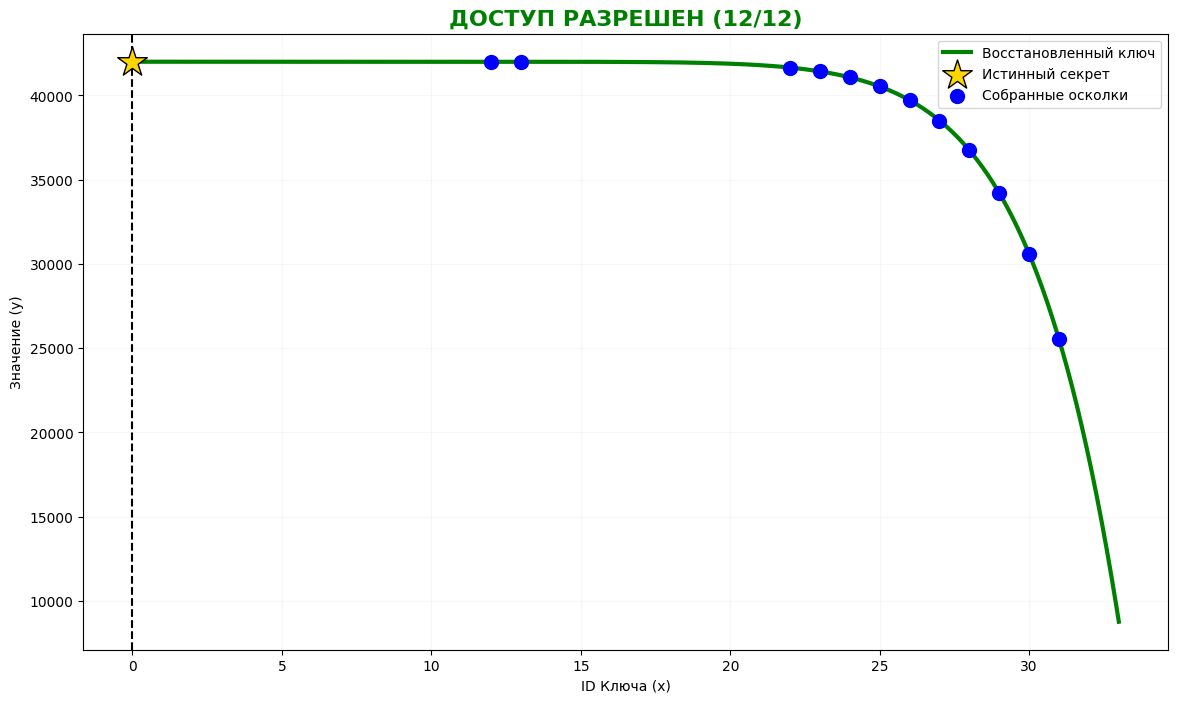


--- Сценарий 2: CEO один ---
Взлом... Не хватает 7 ключей. Генерируем фантомы.


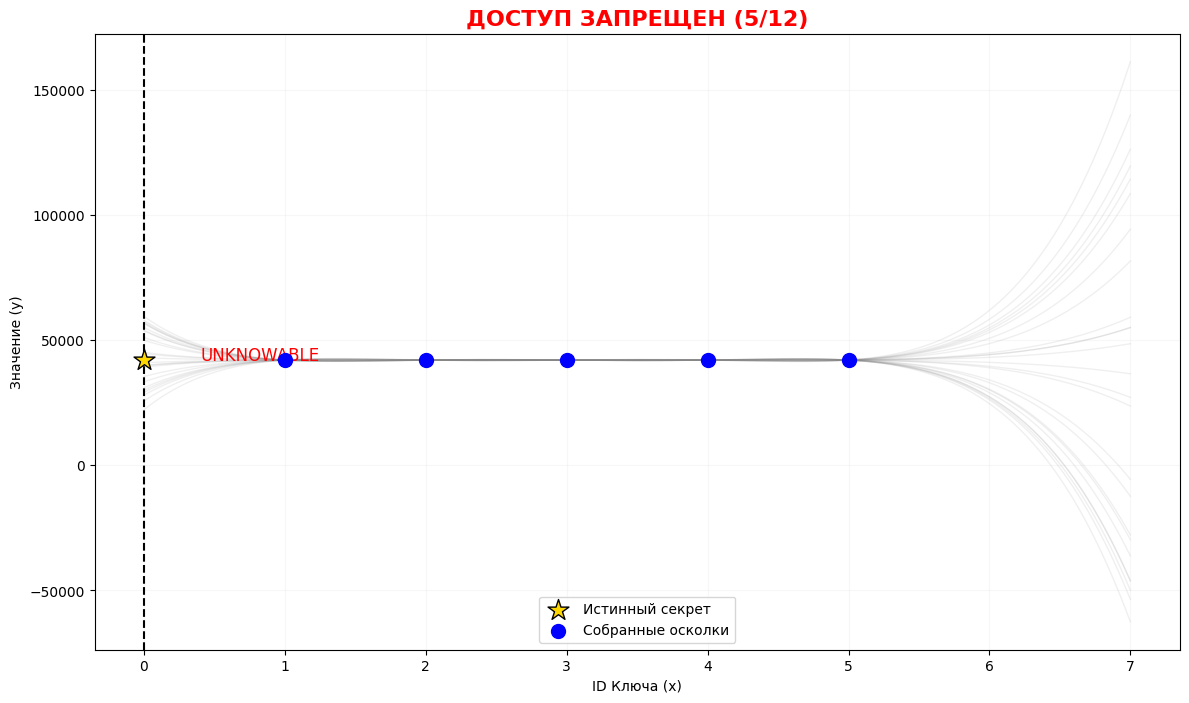


--- Сценарий 3: Переворот (11 из 12) ---
Взлом... Не хватает 1 ключей. Генерируем фантомы.


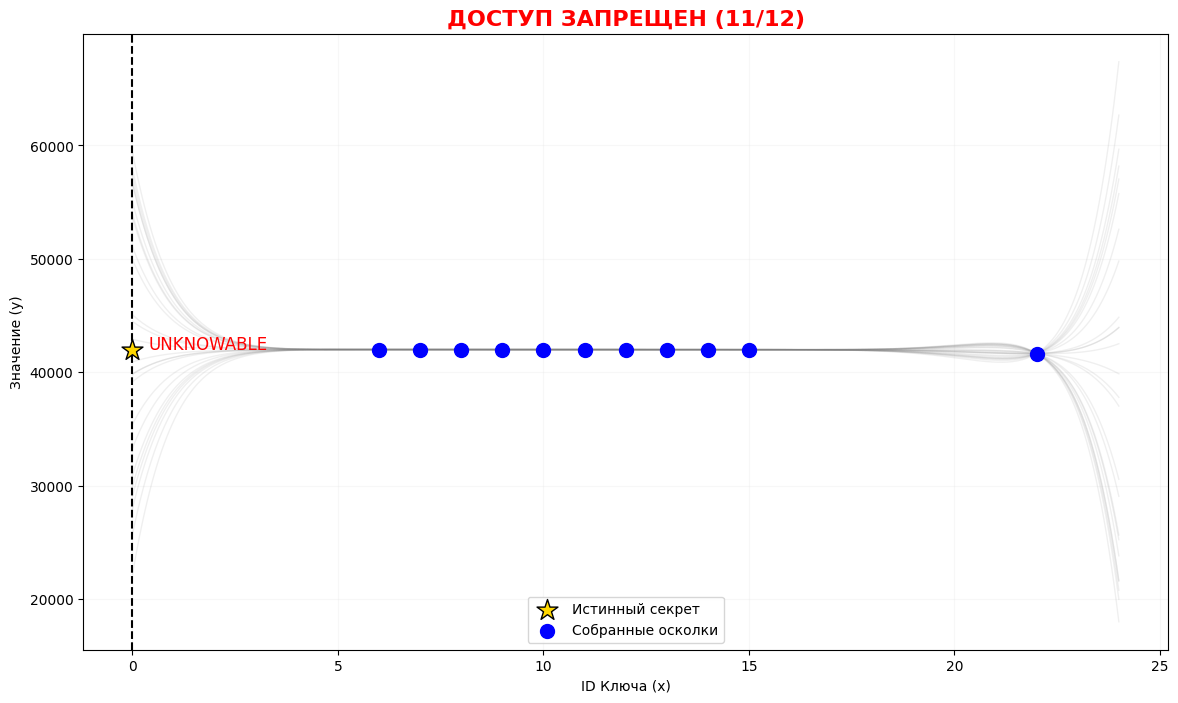


Ответы на вопросы:
1. Если смотреть только на роли, для которых в вопросе заданы цены (стажёры и сеньоры), то минимум сотрудников без CEO: 7 человек (5 сеньоров и 2 стажёров, мощность 12, цена 27k).
   Самая дешёвая комбинация: 1 сеньор и 10 стажёров, итого 15k и мощность 12.
2. Потеря одного бронзового ключа систему не ломает: суммарная мощность падает с 31 до 30, что всё равно намного выше порога 12. В сумме можно потерять до 19 осколков, и 12 ещё останутся.
3. При ошибке всего +0.001 в одном y восстановленный секрет сместился на -12.162941. Это не случайное число, а детерминированный сдвиг, но он может быть заметно больше самой ошибки из-за чувствительности интерполяции.
4. В базовой схеме Шамира нельзя просто «отозвать» один ключ. Нужно выбрать новый секрет или хотя бы новый полином и перевыдать свежие ключи всем остальным участникам.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from scipy.interpolate import lagrange
from numpy.polynomial.polynomial import Polynomial

# Настройки стиля
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'grid.color': '#E6E6E6'})


# БЛОК 1: ядро безопасности (задание 1)

class OmegaProtocol:
    def __init__(self, secret, threshold):
        self.secret = secret
        self.k = threshold
        
        # Делаем старшие коэффициенты маленькими, чтобы графики были наглядными и не улетали по масштабу
        np.random.seed(163)
        scales = 10.0 ** np.arange(self.k + 1, 2, -1)
        coeffs = np.random.randint(-9, 10, size=self.k - 1) / scales
        if coeffs[0] == 0:
            coeffs[0] = 3 / scales[0]
        coeffs = np.append(coeffs, self.secret)
        self.poly = np.poly1d(coeffs)
        
        # Счетчик для координат X (чтобы не выдавать одинаковые x разным людям)
        self.current_x_index = 1 

    def issue_keys(self, role_name, weight, count_people):
        """
        Выдает ключи группе людей.
        role_name: название роли (например, "CEO")
        weight: сколько точек (осколков) получает один человек этой роли
        count_people: сколько людей в этой роли
        """
        issued = {}
        for i in range(1, count_people + 1):
            person_id = f"{role_name}_{i}"
            keys = []
            
            for _ in range(weight):
                x = self.current_x_index
                y = float(self.poly(x))
                keys.append((x, y))
                self.current_x_index += 1
            
            issued[person_id] = keys
        return issued

# БЛОК 2: логика взлома и визуализация (задание 2)

def attempt_activation(protocol, coalition_keys):
    """
    protocol: экземпляр класса OmegaProtocol
    coalition_keys: плоский список ключей [(x1,y1), (x2,y2)...] всех собравшихся
    """
    # 1. Распаковка данных
    if not coalition_keys:
        print("Нет ключей!")
        return
        
    x_shares = np.array([k[0] for k in coalition_keys], dtype=float)
    y_shares = np.array([k[1] for k in coalition_keys], dtype=float)
    total_power = len(x_shares) # Мощность собранной коалиции
    
    plt.figure(figsize=(14, 8))
    
    # Область отрисовки (по оси X)
    x_plot = np.linspace(0, max(x_shares) + 2, 400)
    
    # --- ВЕТКА 1: НЕДОСТАТОЧНО ПРАВ (FAIL) ---
    if total_power < protocol.k:
        status = f"ДОСТУП ЗАПРЕЩЕН ({total_power}/{protocol.k})"
        color_status = "red"
        
        print(f"Взлом... Не хватает {protocol.k - total_power} ключей. Генерируем фантомы.")
        
        np.random.seed(163)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            for _ in range(25):
                fake_secret = np.random.uniform(protocol.secret * 0.5, protocol.secret * 1.5)
                x_aug = np.append(0, x_shares)
                y_aug = np.append(fake_secret, y_shares)
                fake_poly = np.polyfit(x_aug, y_aug, deg=len(x_aug) - 1)
                y_fake = np.polyval(fake_poly, x_plot)
                plt.plot(x_plot, y_fake, color='gray', alpha=0.12, linewidth=1)
        
        plt.text(0.4, protocol.secret, "UNKNOWABLE", fontsize=12, color='red', ha='left')
        plt.scatter(0, protocol.secret, s=250, marker='*', color='gold', edgecolors='black', zorder=10, label='Истинный секрет')

    # --- ВЕТКА 2: ДОСТАТОЧНО ПРАВ (SUCCESS) ---
    else:
        status = f"ДОСТУП РАЗРЕШЕН ({total_power}/{protocol.k})"
        color_status = "green"
        
        poly_lagrange = lagrange(x_shares[:protocol.k], y_shares[:protocol.k])
        poly_reconstructed = Polynomial(poly_lagrange.coef[::-1])
        y_recon = poly_reconstructed(x_plot)
        recovered_secret = float(poly_reconstructed(0))
        
        plt.plot(x_plot, y_recon, color='green', linewidth=3, label='Восстановленный ключ')
        plt.scatter(0, protocol.secret, s=500, marker='*', color='gold', edgecolors='black', zorder=10, label='Истинный секрет')
        print(f"Восстановленный секрет: {recovered_secret:.6f} (ошибка из-за численной аппроксимации {abs(recovered_secret - protocol.secret):.6f})")

    # Оформление графика
    plt.scatter(x_shares, y_shares, s=100, color='blue', zorder=5, label='Собранные осколки')
    plt.title(status, fontsize=16, color=color_status, fontweight='bold')
    plt.axvline(0, color='black', linestyle='--')
    plt.xlabel("ID Ключа (x)")
    plt.ylabel("Значение (y)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# БЛОК 3: сценарии (ЗАПУСК)

# инициализация (Секрет = 42000, Порог = 12)
OMEGA = OmegaProtocol(secret=42000, threshold=12)

# Раздача ключей
ceo_keys = OMEGA.issue_keys("CEO", weight=5, count_people=1)       
top_keys = OMEGA.issue_keys("TopMngr", weight=3, count_people=2)   
sen_keys = OMEGA.issue_keys("Senior", weight=2, count_people=5)    
int_keys = OMEGA.issue_keys("Intern", weight=1, count_people=10)   

# --- сценарий 1: БУНТ СТАЖЕРОВ ---
# 10 Стажеров (10) + 1 Сеньор (2) = 12. (Должен быть УСПЕХ)
print("\n--- Сценарий 1: Бунт ---")
rebels = []
for k in int_keys.values():
    rebels.extend(k)
rebels.extend(sen_keys["Senior_1"])

attempt_activation(OMEGA, rebels)


# --- сценарий 2: одинокий ВОЛК ---
# Только CEO (5). (Должен быть ПРОВАЛ + Веер линий)
print("\n--- Сценарий 2: CEO один ---")
wolf_pack = []
wolf_pack.extend(ceo_keys["CEO_1"])

attempt_activation(OMEGA, wolf_pack)


# --- сценарий 3: совет директоров (БЕЗ CEO) ---
# 2 Топа (6) + 2 Сеньора (4) + 1 Стажер (1) = 11. (Должен быть ПРОВАЛ)
print("\n--- Сценарий 3: Переворот (11 из 12) ---")
board = []
for k in top_keys.values():
    board.extend(k)
board.extend(sen_keys["Senior_1"])
board.extend(sen_keys["Senior_2"])
board.extend(int_keys["Intern_1"])

attempt_activation(OMEGA, board)


# Ответы на вопросы
min_employees_combo = None
min_cost_combo = None

for seniors in range(0, 6):
    for interns in range(0, 11):
        power = 2 * seniors + interns
        if power >= 12:
            employees = seniors + interns
            cost = seniors * 5 + interns * 1
            combo = {
                'employees': employees,
                'cost': cost,
                'seniors': seniors,
                'interns': interns,
                'power': power
            }

            if min_employees_combo is None or employees < min_employees_combo['employees'] or (
                employees == min_employees_combo['employees'] and cost < min_employees_combo['cost']
            ):
                min_employees_combo = combo

            if min_cost_combo is None or cost < min_cost_combo['cost'] or (
                cost == min_cost_combo['cost'] and employees < min_cost_combo['employees']
            ):
                min_cost_combo = combo

reference_keys = rebels[:OMEGA.k]
x_reference = np.array([pair[0] for pair in reference_keys], dtype=float)
y_reference = np.array([pair[1] for pair in reference_keys], dtype=float)

accurate_secret = float(Polynomial(lagrange(x_reference, y_reference).coef[::-1])(0))
y_corrupted = y_reference.copy()
y_corrupted[-1] += 0.001
secret_with_error = float(Polynomial(lagrange(x_reference, y_corrupted).coef[::-1])(0))
secret_shift = secret_with_error - accurate_secret

print("\nОтветы на вопросы:")
print(
    "1. Если смотреть только на роли, для которых в вопросе заданы цены (стажёры и сеньоры), "
    f"то минимум сотрудников без CEO: {min_employees_combo['employees']} человек "
    f"({min_employees_combo['seniors']} сеньоров и {min_employees_combo['interns']} стажёров, "
    f"мощность {min_employees_combo['power']}, цена {min_employees_combo['cost']}k)."
)
print(
    f"   Самая дешёвая комбинация: {min_cost_combo['seniors']} сеньор и {min_cost_combo['interns']} стажёров, "
    f"итого {min_cost_combo['cost']}k и мощность {min_cost_combo['power']}."
)
print(
    "2. Потеря одного бронзового ключа систему не ломает: суммарная мощность падает с 31 до 30, "
    "что всё равно намного выше порога 12. В сумме можно потерять до 19 осколков, и 12 ещё останутся."
)
print(
    f"3. При ошибке всего +0.001 в одном y восстановленный секрет сместился на {secret_shift:.6f}. "
    "Это не случайное число, а детерминированный сдвиг, но он может быть заметно больше самой ошибки из-за чувствительности интерполяции."
)
print(
    "4. В базовой схеме Шамира нельзя просто «отозвать» один ключ. Нужно выбрать новый секрет или хотя бы новый полином "
    "и перевыдать свежие ключи всем остальным участникам."
)

<a name="function_several_variables"></a>
## **<font color=#FF6100>2. Раздел: функции нескольких переменных**

In [3]:
import numpy as np
from numpy import pi as Pi_, cos as Cos_, sin as Sin_, exp as Exp_, sqrt as Sqrt_, log as Log_, arccos as Arccos_, tan as Tan_, arctan as Atan_, arcsin as Asin_
import matplotlib.pyplot as plt
import math
import plotly.graph_objects as go
import sympy as sp
from sympy import Symbol, symbols, diff, solve, Eq, nsolve, solveset, integrate, Integral, Function, latex, S, simplify, fraction, Union, Interval, intersection, limit, plot, Piecewise, Curve, plot_parametric, plot_implicit, And, nonlinsolve, Matrix, factor, lambdify
from sympy.calculus.util import continuous_domain
from sympy.plotting import plot3d
from sympy.geometry import Point
from sympy import sin as Sin, cos as Cos, tan as Tan, exp as Exp, log as Log, pi as Pi, sqrt as Sqrt, asin as Asin, atan as Atan, oo as Infinity, acos as Acos
%matplotlib inline

<a name="function_several_variables_1_part"></a>
### <font color=#FF6100>Область определения, предел и непрерывность, приращение и дифференциал

<a name="task_3"></a>
**<font color=#FF5EDD>Задача 3**</font>

Вы выступаете в роли аудитора DeFi-протокола. 

Разработчики заявляют, что при минимизации издержек сети (комиссии $g$ и времени блока $t$) эффективность системы стремится к максимуму ($100\%$). Однако архитектура протоколов в многомерном пространстве параметров часто таит в себе неопределенности. Вам необходимо проверить, является ли предел эффективности стабильным или он зависит от стратегии масштабирования сети.

Математическая модель: Функция эффективности протокола (Efficiency Score) задана уравнением:$$E(g, t) = (\cos g)^{\frac{1}{t^2}}$$Где:$g$ — средняя стоимость газа (Gas price), $g \to 0$.$t$ — время финализации блока (Time to finality), $t \to 0$.

*Задание 1: Проверка на устойчивость (Повторные пределы)*

Прежде чем запускать масштабный тест, необходимо проверить, как ведет себя система при поочередном изменении параметров.
* Вычислите предел функции при условии, что комиссия уже обнулена ($g = 0$), а время блока $t$ стремится к 0.
* Вычислите предел функции при фиксированном времени блока ($t = const$), если комиссия $g$ стремится к 0.
* Вопрос: Можно ли на основе этих данных утверждать, что общая эффективность всегда будет равна 1?

*Задание 2: масштабирование*

Предположим, что обновление сети происходит пропорционально: комиссия падает линейно в зависимости от скорости сети.Введем зависимость $g = k \cdot t$, где $k > 0$ — коэффициент пропорциональности. С помощью SymPy, вычислите предел:$$\lim_{t \to 0} E(kt, t)$$Анализ: Как значение коэффициента $k$ влияет на итоговый результат? Рассчитайте конкретные значения эффективности для $k = 1$ и $k = 3$.

*Задание 3: Моделирование сценария «L2 Scaling»*

Рассмотрим ситуацию, когда технологический апгрейд позволил радикально уменьшить время блока, но оптимизация комиссий за ним не поспевает.
* Найдите предел эффективности в случае, если комиссия затухает медленнее, чем время блока, по закону $g = \sqrt{t}$.
* Сформулируйте математический вывод: к чему придет протокол при таком сценарии масштабирования?

In [4]:
# Задача 3
g, t, k = symbols('g t k', positive=True)
E = Cos(g) ** (1 / t**2)

# 1. Повторные пределы
limit_after_g_zero = limit(E.subs(g, 0), t, 0)
limit_g_to_zero = limit(E, g, 0)

print("1. Повторные пределы:")
print("   lim_{t->0} E(0, t) =", limit_after_g_zero)
print("   lim_{g->0} E(g, t) =", limit_g_to_zero)
print("   Этих двух фактов недостаточно, чтобы утверждать существование общего предела: нужно проверить траектории подхода.")

# 2. Масштабирование g = k * t
scaled_limit = simplify(limit(E.subs(g, k * t), t, 0))
value_k1 = scaled_limit.subs(k, 1).evalf()
value_k3 = scaled_limit.subs(k, 3).evalf()

print("\n2. Масштабирование g = k * t:")
print("   lim_{t->0} E(k t, t) =", scaled_limit)
print(f"   При k = 1 получаем {value_k1}")
print(f"   При k = 3 получаем {value_k3}")
print("   Чем больше k, тем сильнее итоговая эффективность падает, потому что экспонента exp(-k^2 / 2) убывает.")

# 3. Медленное затухание комиссии: g = sqrt(t)
slow_limit = limit(E.subs(g, Sqrt(t)), t, 0, dir='+')

print("\n3. Сценарий g = sqrt(t):")
print("   lim_{t->0} E(sqrt(t), t) =", slow_limit)
print("   Вывод: если комиссия убывает медленнее, чем время блока, эффективность проваливается к 0, а не к 1.")

1. Повторные пределы:
   lim_{t->0} E(0, t) = 1
   lim_{g->0} E(g, t) = 1
   Этих двух фактов недостаточно, чтобы утверждать существование общего предела: нужно проверить траектории подхода.

2. Масштабирование g = k * t:
   lim_{t->0} E(k t, t) = exp(-k**2/2)
   При k = 1 получаем 0.606530659712633
   При k = 3 получаем 0.0111089965382423
   Чем больше k, тем сильнее итоговая эффективность падает, потому что экспонента exp(-k^2 / 2) убывает.

3. Сценарий g = sqrt(t):
   lim_{t->0} E(sqrt(t), t) = 0
   Вывод: если комиссия убывает медленнее, чем время блока, эффективность проваливается к 0, а не к 1.


<a name="task_4"></a>
**<font color=#FF5EDD>Задача 4**</font> 

*Уровень пыльцы*

В тихом и уютном городке под названием «Долина математиков» раскинулся плодовый сад. Координаты его — $(0,0)$, то есть прямо в центре мира (по мнению местных пчёл). С наступлением весны здесь происходит настоящее буйство цветения, а вместе с ним — и великое нашествие пыльцы.

Математик Аркадий, вдохновлённый не только красотой природы, но и мощным чиханием, вывел формулу, которая описывает пыльцевой индекс — показатель того, насколько сильно здесь может заложить нос:

$$
f(x, y) = \frac{\sin(x^3 y)}{x^2 + y^2}
$$

- Здесь $(x, y)$ — это Ваши координаты.
- В числителе — $\sin(x^3 y)$ — не просто синус, а синус со странностями: он отражает таинственные колебания пыльцевого потока, зависящие от того, как именно Вы отклонились от центра.
- В знаменателе — $x^2 + y^2$, и он напоминает нам, что чем дальше вы убегаете от сада, тем больше пыльца начинает лениться и оседать.

Но есть одно но: в самом центре — в точке $(0,0)$ — происходит что-то загадочное. Формула там *не определена* — ведь мы получаем $\tfrac{0}{0}$, математическую версию «мы не уверены, но возможно произойдёт пыльцевой апокалипсис».

Аркадий решил ответить на волнующий всех чихающих математиков вопрос:  
«А что вообще происходит с пыльцевым индексом *вблизи* центра? Он стремится к чему-то конкретному?»

Помогите Аркадию:)

In [5]:
# Задача 4
x, y, m = symbols('x y m', real=True)
f_4 = Sin(x**3 * y) / (x**2 + y**2)

line_limit = simplify(limit(f_4.subs(y, m * x), x, 0))
parabola_limit = simplify(limit(f_4.subs(y, x**2), x, 0))
axis_limit = simplify(limit(f_4.subs(x, 0), y, 0))

print("Пределы по разным траекториям:")
print("1. По прямой y = m * x:", line_limit)
print("2. По параболе y = x^2:", parabola_limit)
print("3. По оси x = 0:", axis_limit)

answer_4 = 0

Пределы по разным траекториям:
1. По прямой y = m * x: 0
2. По параболе y = x^2: 0
3. По оси x = 0: 0


Так как $| \sin(u) | \leq |u|$, то $|f(x, y)| \leq \frac{|x^3 y|}{x^2 + y^2}$

Кроме того, $|xy| \leq \frac{x^2 + y^2}{2}$, значит $\frac{|x^3 y|}{x^2 + y^2} \leq \frac{x^2}{2}$

Следовательно общий предел существует и равен 0

<a name="task_5"></a>
**<font color=#FF5EDD>Задача 5**</font> 

Вам дана следующая функция:
$$
f(x, y) = \ln\left(\frac{x}{y}\right) + e^{\frac{x}{y}}
$$
1. Построить линии уровня.
2. Найти полный дифференциал функции.

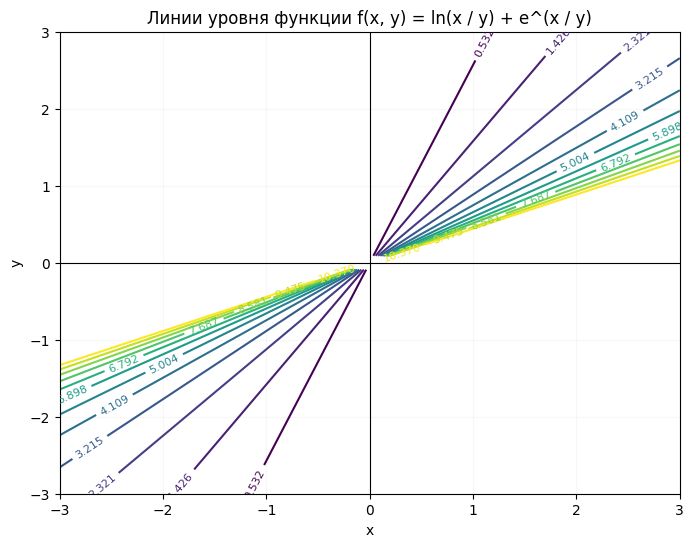

Частная производная по x: exp(x/y)/y + 1/x
Частная производная по y: (-x*exp(x/y) - y)/y**2
Полный дифференциал df = (dx*y - dy*x)*(x*exp(x/y) + y)/(x*y**2)


In [6]:
x, y = symbols('x y')
dx, dy = symbols('dx dy')

# Нельзя менять переменную f_5
f_5 = Log(x/y) + Exp(x/y)

df_dx = simplify(diff(f_5, x))
df_dy = simplify(diff(f_5, y))
answer_5 = simplify(df_dx * dx + df_dy * dy)

grid = np.linspace(-3, 3, 500)
X, Y = np.meshgrid(grid, grid)
Z = np.full_like(X, np.nan, dtype=float)

mask = (X * Y > 0) & (np.abs(Y) > 0.08)
with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
    Z[mask] = np.log(X[mask] / Y[mask]) + np.exp(X[mask] / Y[mask])

finite_mask = np.isfinite(Z)
finite_values = Z[finite_mask]
levels = np.linspace(np.percentile(finite_values, 20), np.percentile(finite_values, 80), 12)

plt.figure(figsize=(8, 6))
contours = plt.contour(X, Y, Z, levels=levels, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Линии уровня функции f(x, y) = ln(x / y) + e^(x / y)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.show()

print("Частная производная по x:", df_dx)
print("Частная производная по y:", df_dy)
print("Полный дифференциал df =", answer_5)